            medalist_name                  Sport   Medal Gender
0            Bair Badënov                archery  bronze   male
1           Ilario Di Buò                archery  silver   male
2            Im Dong-hyun                archery    gold   male
3               Jiang Lin                archery  bronze   male
4          Lee Chang-hwan                archery    gold   male
...                   ...                    ...     ...    ...
1870        Steeve Guénot  greco-roman_wrestling    gold   male
1871  Yannick Szczepaniak  greco-roman_wrestling  bronze   male
1872       Yavor Yanakiev  greco-roman_wrestling  bronze   male
1873      Yury Patrikeyev  greco-roman_wrestling  bronze   male
1874         Zoltán Fodor  greco-roman_wrestling  silver   male

[1875 rows x 4 columns]


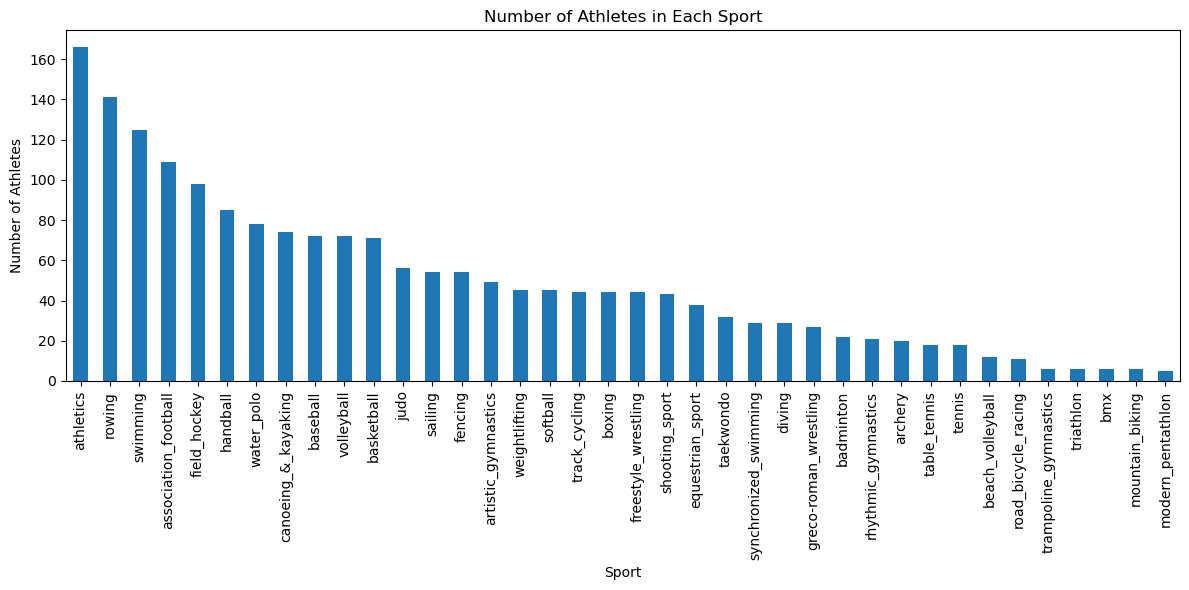

Gender
male      1032
female     843
Name: count, dtype: int64


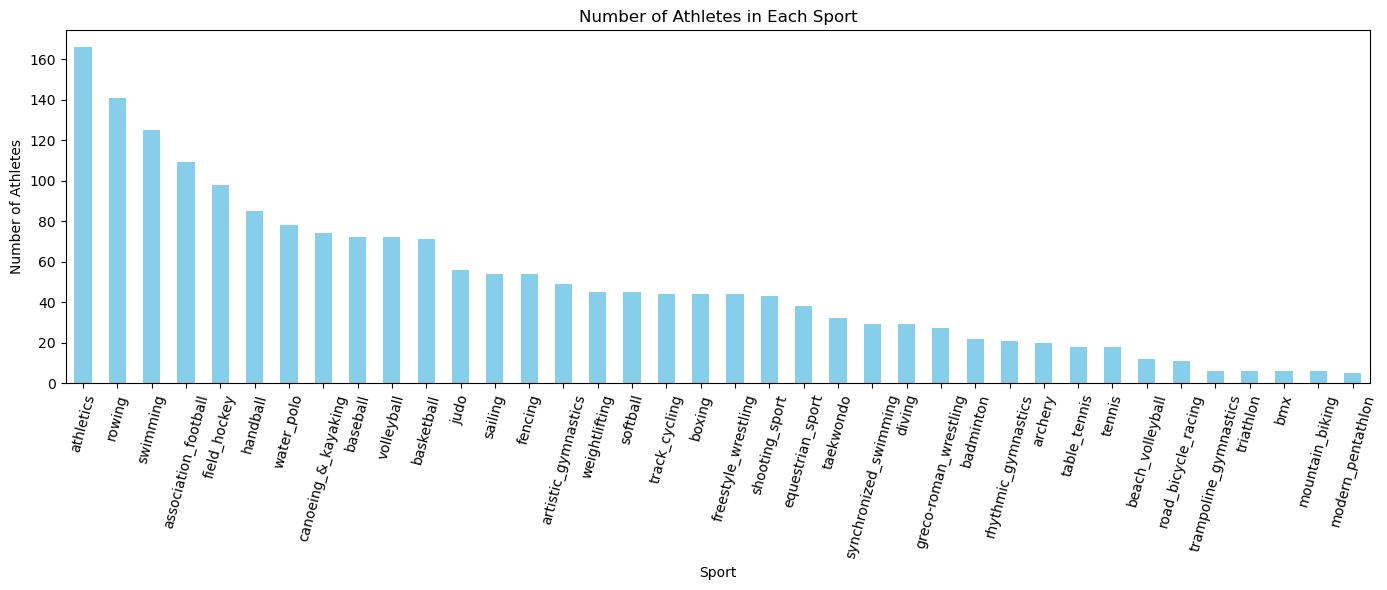

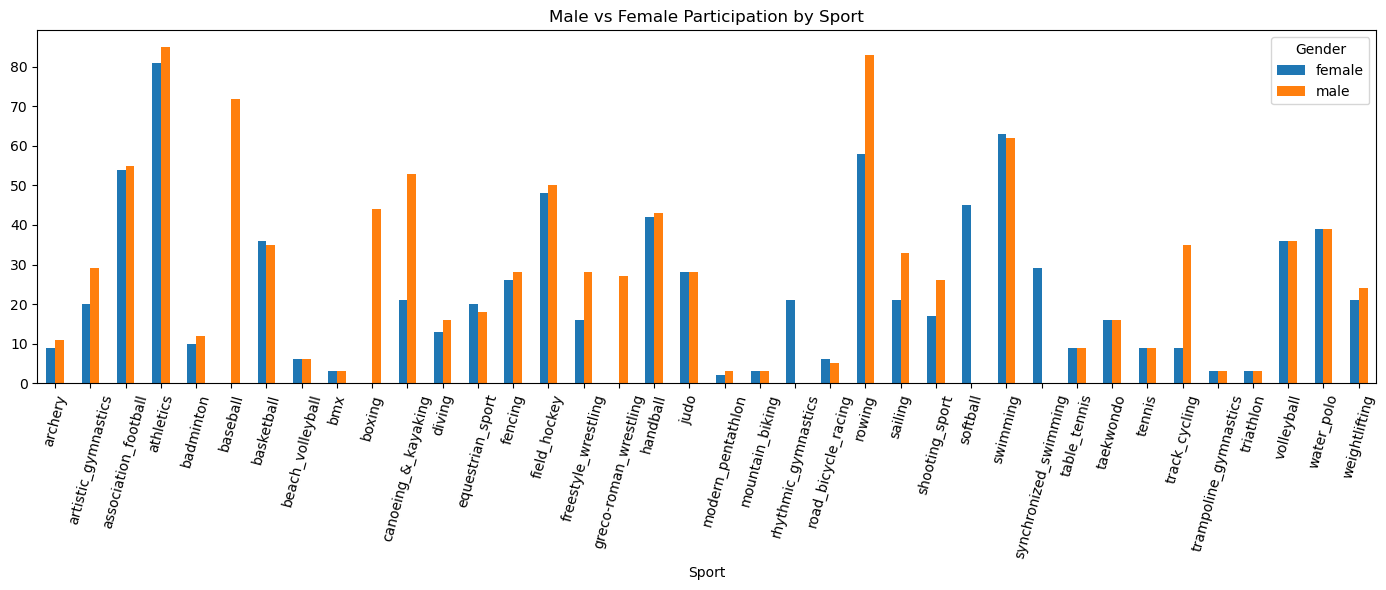

Gender                 female  male
Sport                              
archery                     9    11
artistic_gymnastics        20    29
association_football       54    55
athletics                  81    85
badminton                  10    12
baseball                    0    72
basketball                 36    35
beach_volleyball            6     6
bmx                         3     3
boxing                      0    44
canoeing_&_kayaking        21    53
diving                     13    16
equestrian_sport           20    18
fencing                    26    28
field_hockey               48    50
freestyle_wrestling        16    28
greco-roman_wrestling       0    27
handball                   42    43
judo                       28    28
modern_pentathlon           2     3
mountain_biking             3     3
rhythmic_gymnastics        21     0
road_bicycle_racing         6     5
rowing                     58    83
sailing                    21    33
shooting_sport             1

In [16]:
import pandas as pd

# Use the read_csv function to load the data into a DataFrame
# Ensure the path to your CSV file is correct (relative or absolute)
df = pd.read_csv('olympics_08_medalists.csv') 

# Display the first few rows of the DataFrame (useful in a Jupyter Notebook)
value_vars = [col for col in df.columns if col != 'medalist_name']

df_melted = pd.melt(
    df,
    id_vars=['medalist_name'],
    value_vars=value_vars,
    var_name='Sport',
    value_name='Medal'
)

df_melted = df_melted.dropna(subset=['Medal'])
df_melted = df_melted.reset_index(drop=True)

df_melted[['Gender', 'Sport']] = df_melted['Sport'].str.split('_', n=1, expand=True)

df_melted['Sport'] = df_melted['Sport'].str.replace(' and ', ' & ')
df_melted['Sport'] = df_melted['Sport'].str.replace(' ', '_')
df_melted = df_melted.dropna(subset=['Medal']).reset_index(drop=True)

print(df_melted)

sport_counts = df_melted['Sport'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sport_counts.plot(kind='bar')

plt.title('Number of Athletes in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')

plt.xticks(rotation=90)  # rotate labels so they fit
plt.tight_layout()

plt.show()

gender_counts = df_melted['Gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(14, 6))
sport_counts.plot(kind='bar', color='skyblue')

plt.title('Number of Athletes in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

gender_sport_counts = df_melted.groupby(['Sport', 'Gender']).size().unstack(fill_value=0)

gender_sport_counts.plot(kind='bar', figsize=(14, 6))
plt.title('Male vs Female Participation by Sport')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


pivot_table = pd.pivot_table(
    df_melted,
    index='Sport',
    columns='Gender',
    values='Medal',
    aggfunc='count',
    fill_value=0
)

print(pivot_table)